accuracy 0    0.772727
dtype: float64 cost [0    0.25584
dtype: float64, 0    0.25397
dtype: float64, 0    0.252705
dtype: float64, 0    0.251549
dtype: float64, 0    0.250391
dtype: float64, 0    0.249749
dtype: float64, 0    0.257387
dtype: float64, 0    0.254163
dtype: float64, 0    0.25343
dtype: float64, 0    0.255859
dtype: float64, 0    0.252285
dtype: float64, 0    0.248181
dtype: float64, 0    0.247546
dtype: float64, 0    0.247423
dtype: float64, 0    0.247386
dtype: float64, 0    0.247373
dtype: float64, 0    0.247374
dtype: float64, 0    0.247384
dtype: float64, 0    0.247401
dtype: float64, 0    0.247426
dtype: float64, 0    0.247457
dtype: float64, 0    0.247494
dtype: float64, 0    0.247536
dtype: float64, 0    0.247585
dtype: float64, 0    0.247639
dtype: float64, 0    0.2477
dtype: float64, 0    0.247768
dtype: float64, 0    0.247843
dtype: float64, 0    0.247927
dtype: float64, 0    0.248022
dtype: float64, 0    0.248129
dtype: float64, 0    0.24825
dtype: float64, 0 

C:\Users\panda\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\_core\fromnumeric.py:84: FutureWarning: The behavior of DataFrame.sum with axis=None is deprecated, in a future version this will reduce over both axes and return a scalar. To retain the old behavior, pass axis=0 (or do not pass axis)
  return reduction(axis=axis, out=out, **passkwargs)


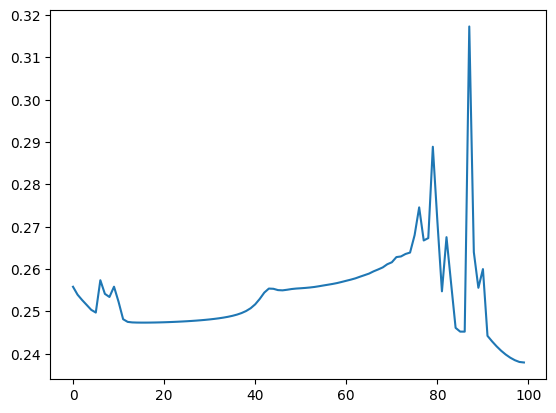

In [9]:
import numpy as np
import pandas as pd
from typing import Tuple
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split

# read_data, get_df_shape, data_split are the same as HW3
def read_data(filename: str) -> pd.DataFrame:
    d = pd.read_csv(filename)
    df = pd.DataFrame(data=d)
    return df

def extract_features_label(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series]:
    # Filter the dataframe to include only Setosa and Virginica rows
    
    # (###NET1 & NET2### i)
    filtered_df = df[df['variety'].isin(['Versicolor', 'Virginica'])]
    features = filtered_df[['sepal.length', 'sepal.width']] # accuracy .54
    labels = filtered_df['variety'].map({'Versicolor': 0, 'Virginica': 1})
    
    # Extract the required features and labels from the filtered dataframe
    
    # (###NET1 & NET2### ii)
    #filtered_df = df[df['variety'].isin(['Setosa', 'Virginica'])]
    #features = filtered_df[['petal.length', 'petal.width']] # accuracy 1.0
    #labels = filtered_df['variety'].map({'Setosa': 0, 'Virginica': 1})
    
    # (tests I ran for NET1)
    #features = filtered_df[['sepal.length', 'petal.width']] # accuracy 1.0
    #features = filtered_df[['petal.length', 'sepal.width']] # accuracy 1.0
    
    # (###NET4### four features i) 
    #filtered_df = df[df['variety'].isin(['Versicolor', 'Virginica'])]
    #features = filtered_df[['sepal.length', 'sepal.width','petal.length', 'petal.width']] # accuracy .54
    #labels = filtered_df['variety'].map({'Versicolor': 0, 'Virginica': 1})
    
    # (###NET4### four features ii)
    #filtered_df = df[df['variety'].isin(['Setosa', 'Virginica'])]
    #features = filtered_df[['sepal.length', 'sepal.width','petal.length', 'petal.width']] # accuracy 1.0
    #labels = filtered_df['variety'].map({'Setosa': 0, 'Virginica': 1})

    return features, labels

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def function_derivative(z):
    fd = sigmoid(z)
    return fd * (1 - fd)


class NN:
    def __init__(self, features,hidden_layers, hidden_neurons, output_neurons, learning_rate):
        self.features = features
        self.hidden_neurons = hidden_neurons
        self.hidden_neurons_2 = hidden_neurons
        self.output_neurons = output_neurons
        self.learning_rate = learning_rate
        
        # initialize weights
        self.V = np.random.randn(self.features, self.hidden_neurons)
        self.E = np.random.randn(self.hidden_neurons,self.hidden_neurons_2)
        self.W = np.random.randn(self.hidden_neurons, self.output_neurons)
        
        # initialize biases: 0
        self.V0 = np.zeros((self.hidden_neurons))
        self.E0 = np.zeros((self.hidden_neurons_2))
        self.W0 = np.zeros((self.output_neurons))
        #print (self.V,self.E,self.W)
    def train(self, X, t, epochs=1000):
        costs = []
        for epoch in range(epochs):
            # forward pass
            net_u = X.dot(self.V) + self.V0
            H = sigmoid(net_u)
            net_e = H.dot(self.E) + self.E0
            H2 = sigmoid(net_e)
            net_z = H.dot(self.W) + self.W0
            O = sigmoid(net_z)
            
            # backpropagation pass
            error_output = O - t
          
            d_W = H2.T.dot(error_output * function_derivative(net_z))
            d_W0 = np.sum(error_output * function_derivative(net_z), axis=0)
           
            error_hidden_layer_2 = error_output.dot(self.W.T) * function_derivative(net_e)
            d_E = H.T.dot(error_hidden_layer_2)
            d_E0 = np.sum(error_hidden_layer_2,axis=0)

            error_hidden_layer = error_hidden_layer_2.dot(self.E.T) * function_derivative(net_u)
            
            d_V = X.T.dot(error_hidden_layer)
            d_V0 = np.sum(error_hidden_layer, axis=0)
            
            # update weights and biases
            self.W -= self.learning_rate * d_W
            self.W0 -= self.learning_rate * d_W0
            self.E -= self.learning_rate * d_E
            self.E0 -= self.learning_rate * d_E0
            self.V -= self.learning_rate * d_V
            self.V0 -= self.learning_rate * d_V0
            
            #find the cost function
            if epoch % 10 == 0:
                loss =  np.square(np.subtract(t,O)).mean() 
                costs.append(loss)
                
        return costs
    
    def predict(self, X):
        net_u = X.dot(self.V) + self.V0
        H = sigmoid(net_u)
        net_z = H.dot(self.W) + self.W0
        O = sigmoid(net_z)
     
        return (O > 0.5).astype(int)
    
if __name__ == "__main__":
    def accuracy(t, y_pred):
        accuracy = np.sum(t == y_pred) / len(t)
        return accuracy

    # Read the data
    train_df = read_data("./iris_training_data.csv")
    test_df = read_data("./iris_testing_data.csv")
    
    X, t =  extract_features_label(train_df)
    X_test, t_test = extract_features_label(test_df)

    t = t.values.reshape([len(t),1])
    t_test = t_test.values.reshape([len(t_test),1])
    
nn = NN(features=2,hidden_layers=2, hidden_neurons=7, output_neurons=1, learning_rate=0.01)



# train the network
cost = nn.train(X, t)

# make predictions on the test data
y_pred = nn.predict(X_test)

# evaluate the accuracy
acc = accuracy(t_test,y_pred)
print('accuracy',acc,'cost',cost)#
  
plt.plot(cost)
plt.show()
